# 🍷 Semana 10: Wine Quality - Series de Tiempo
## Dataset: Wine Quality (Calidad de vino tinto)

**Objetivo:** Predecir la calidad del vino (escala 0-10) simulando una serie temporal ordenada por cosecha.

**Modelos a competir:**
- **ARIMA / SARIMA** (modelos autorregresivos clásicos)
- **Prophet** (modelo de Facebook para series temporales)
- **Rolling Windows** (promedios móviles para suavizar)

**Métricas de evaluación:** RMSE, MAE, MAPE

**Contexto de negocio:** Una bodega quiere predecir la calidad del vino antes de embotellarlo, para separar lotes de alta calidad para exportación.

---

### ¿Qué es?
Dataset de **6,497 muestras** de vino tinto, con 11 características químicas:
- Acidez fija, acidez volátil, ácido cítrico
- Azúcar residual, cloruros, dióxido de azufre libre/total
- Densidad, pH, sulfatos, alcohol

**Target:** Calidad del vino (escala 0-10)

### ¿Qué problema resuelve?
Predecir la **calidad del vino** basándose en su composición química, **simulando una serie temporal** (orden por cosecha).

### El Reto
**Series de Tiempo** - Simulamos que las muestras están ordenadas temporalmente (por cosecha) para predecir valores futuros.

### Contexto de negocio
Una bodega quiere predecir la calidad del vino antes de embotellarlo, para separar lotes de alta calidad para exportación.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 10: WINE QUALITY - SERIES DE TIEMPO
# ======================================================

# Instalar librerías necesarias
!pip install scikit-learn pandas numpy matplotlib seaborn statsmodels prophet -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Semilla
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset Wine Quality y lo preparamos como serie temporal (ordenado por índice simulando cosechas).

In [2]:
print("="*60)
print("📊 CARGANDO DATASET WINE QUALITY")
print("="*60)

# Cargar dataset
data = fetch_openml(data_id=44136, as_frame=True)
df = data.frame

# Verificar nombre de la columna target
target_col = 'quality' if 'quality' in df.columns else df.columns[-1]

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {df.shape[0]:,} muestras × {df.shape[1]} características")
print(f"🎯 Target: {target_col} (calidad del vino, escala 0-10)")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(df.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(df.describe())

📊 CARGANDO DATASET WINE QUALITY

✅ Dataset cargado exitosamente
📊 SHAPE: 6,497 muestras × 12 características
🎯 Target: quality (calidad del vino, escala 0-10)

📋 Primeras 5 filas del dataset:


,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0



📊 Estadísticas descriptivas:


,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


📈 ANÁLISIS DE LA VARIABLE OBJETIVO

📊 Estadísticas de Calidad:
   • Media: 5.82
   • Mediana: 6.00
   • Desviación estándar: 0.87
   • Mínimo: 3
   • Máximo: 9


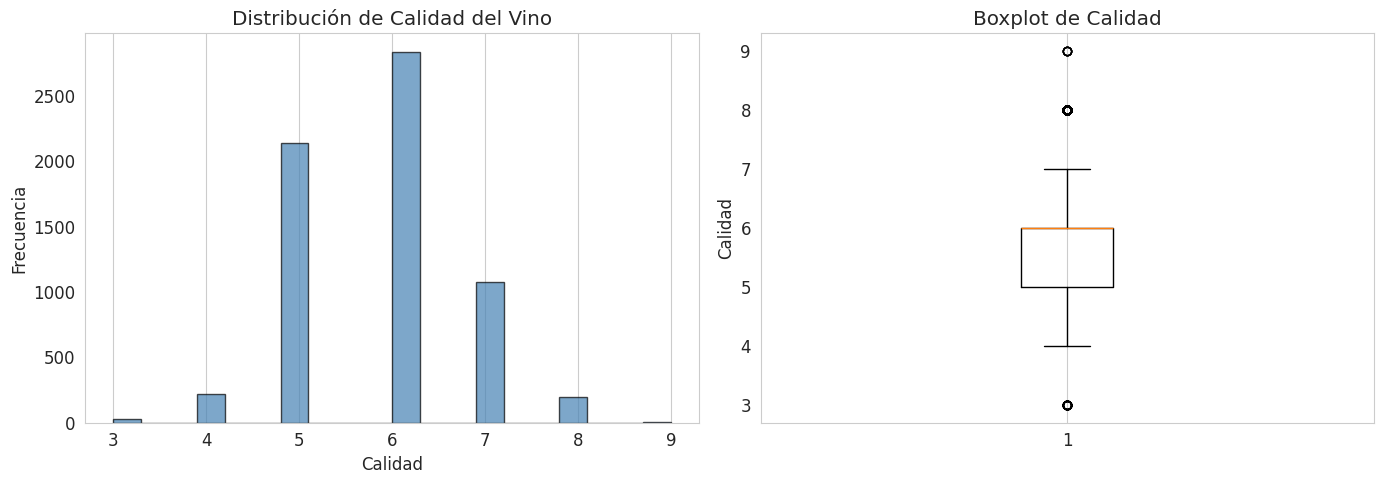


📊 Distribución por valor de calidad:
   • Calidad 3: 30 muestras (0.5%)
   • Calidad 4: 216 muestras (3.3%)
   • Calidad 5: 2138 muestras (32.9%)
   • Calidad 6: 2836 muestras (43.7%)
   • Calidad 7: 1079 muestras (16.6%)
   • Calidad 8: 193 muestras (3.0%)
   • Calidad 9: 5 muestras (0.1%)


In [3]:
# Análisis de la variable objetivo (calidad)
print("="*60)
print("📈 ANÁLISIS DE LA VARIABLE OBJETIVO")
print("="*60)

y = df[target_col].values

# Estadísticas
print(f"\n📊 Estadísticas de Calidad:")
print(f"   • Media: {y.mean():.2f}")
print(f"   • Mediana: {np.median(y):.2f}")
print(f"   • Desviación estándar: {y.std():.2f}")
print(f"   • Mínimo: {y.min():.0f}")
print(f"   • Máximo: {y.max():.0f}")

# Distribución de calidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(y, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Calidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Calidad del Vino')
axes[0].grid(axis='y')

# Boxplot
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Calidad')
axes[1].set_title('Boxplot de Calidad')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

# Conteo por valor de calidad
print("\n📊 Distribución por valor de calidad:")
quality_counts = df[target_col].value_counts().sort_index()
for quality, count in quality_counts.items():
    print(f"   • Calidad {quality:.0f}: {count} muestras ({count/len(df)*100:.1f}%)")

## 3. Preparación de la Serie Temporal

Simulamos que las muestras están ordenadas temporalmente (por cosecha) y creamos una serie de tiempo.

🔄 PREPARACIÓN DE LA SERIE TEMPORAL

📊 Serie temporal creada:
   • Período: 2010-01-01 hasta 2027-10-15
   • Frecuencia: diaria (simulando cosechas diarias)
   • Total de observaciones: 6497


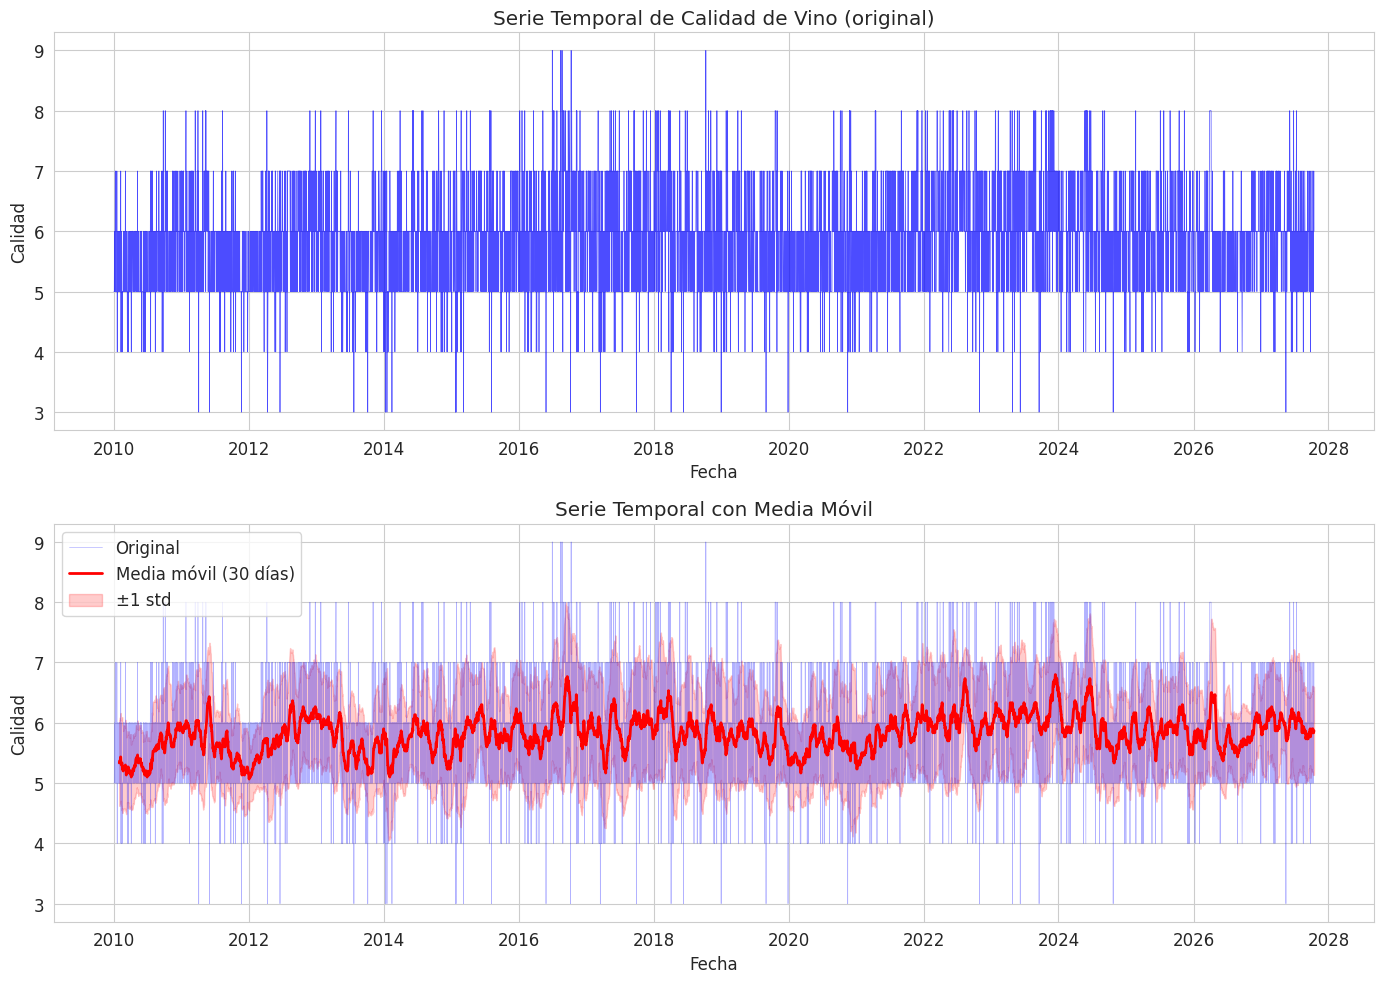


📊 División temporal:
   • Entrenamiento: 5197 muestras (2024-03-24)
   • Prueba: 1300 muestras (2027-10-15)

⚠️ NOTA: No se usó shuffle para respetar el orden temporal


In [4]:
print("="*60)
print("🔄 PREPARACIÓN DE LA SERIE TEMPORAL")
print("="*60)

# Crear serie temporal simulada (ordenada por índice)
# Asumimos que las muestras están ordenadas cronológicamente por cosecha
series = pd.Series(y, name='quality')

# Crear índice de tiempo (fechas simuladas)
dates = pd.date_range(start='2010-01-01', periods=len(series), freq='D')
series.index = dates

print(f"\n📊 Serie temporal creada:")
print(f"   • Período: {dates[0].date()} hasta {dates[-1].date()}")
print(f"   • Frecuencia: diaria (simulando cosechas diarias)")
print(f"   • Total de observaciones: {len(series)}")

# Visualización de la serie temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Serie original
axes[0].plot(series.index, series.values, 'b-', alpha=0.7, linewidth=0.5)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Calidad')
axes[0].set_title('Serie Temporal de Calidad de Vino (original)')
axes[0].grid(True)

# Rolling mean para suavizar
rolling_mean = series.rolling(window=30).mean()
rolling_std = series.rolling(window=30).std()

axes[1].plot(series.index, series.values, 'b-', alpha=0.3, linewidth=0.5, label='Original')
axes[1].plot(series.index, rolling_mean, 'r-', linewidth=2, label='Media móvil (30 días)')
axes[1].fill_between(series.index, rolling_mean - rolling_std, rolling_mean + rolling_std,
                     alpha=0.2, color='red', label='±1 std')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Calidad')
axes[1].set_title('Serie Temporal con Media Móvil')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Dividir en entrenamiento (80%) y prueba (20%) - SIN SHUFFLE (respetando orden temporal)
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]

print(f"\n📊 División temporal:")
print(f"   • Entrenamiento: {len(train)} muestras ({dates[train_size-1].date()})")
print(f"   • Prueba: {len(test)} muestras ({dates[-1].date()})")
print(f"\n⚠️ NOTA: No se usó shuffle para respetar el orden temporal")

## 4. Análisis de Autocorrelación (ACF y PACF)

El análisis de autocorrelación ayuda a identificar la dependencia temporal en los datos.

📊 ANÁLISIS DE AUTOCORRELACIÓN

🔍 Prueba de Estacionariedad (Dickey-Fuller):
   • Estadístico ADF: -12.4015
   • p-valor: 0.0000
   • Valores críticos:
       1%: -3.4316
       5%: -2.8621
       10%: -2.5671
   ✅ La serie es estacionaria (p-valor < 0.05)


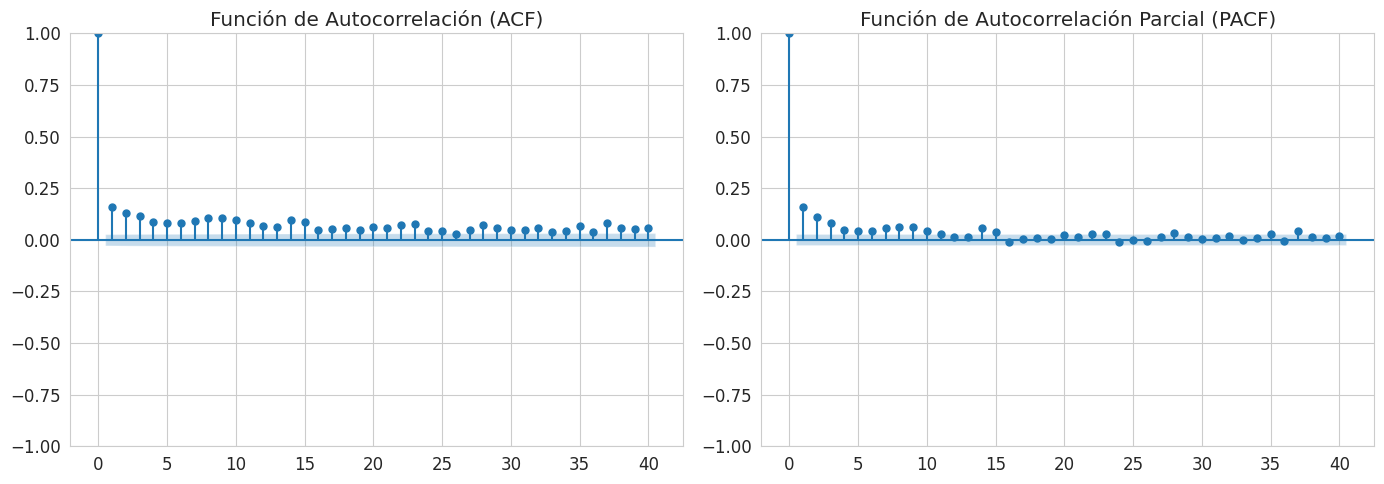


📖 INTERPRETACIÓN:
   • ACF: Mide correlación con rezagos anteriores
   • PACF: Mide correlación directa eliminando efectos intermedios
   • Las barras fuera del área sombreada son estadísticamente significativas


In [5]:
print("="*60)
print("📊 ANÁLISIS DE AUTOCORRELACIÓN")
print("="*60)

# Prueba de estacionariedad (Dickey-Fuller)
print("\n🔍 Prueba de Estacionariedad (Dickey-Fuller):")
result = adfuller(train)
print(f"   • Estadístico ADF: {result[0]:.4f}")
print(f"   • p-valor: {result[1]:.4f}")
print(f"   • Valores críticos:")
for key, value in result[4].items():
    print(f"       {key}: {value:.4f}")

if result[1] < 0.05:
    print(f"   ✅ La serie es estacionaria (p-valor < 0.05)")
else:
    print(f"   ⚠️ La serie NO es estacionaria (se可能需要 diferenciación)")

# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train, ax=axes[0], lags=40, alpha=0.05)
axes[0].set_title('Función de Autocorrelación (ACF)')
axes[0].grid(True)

plot_pacf(train, ax=axes[1], lags=40, alpha=0.05, method='ywm')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN:")
print("   • ACF: Mide correlación con rezagos anteriores")
print("   • PACF: Mide correlación directa eliminando efectos intermedios")
print("   • Las barras fuera del área sombreada son estadísticamente significativas")

## 5. Modelo 1: Rolling Windows (Promedios Móviles)

Los promedios móviles suavizan la serie y permiten hacer predicciones simples.

📊 MODELO 1: ROLLING WINDOWS

🔍 Probando diferentes tamaños de ventana...
   • Ventana=7: RMSE=1.0594, MAE=0.9035, MAPE=16.85%
   • Ventana=14: RMSE=1.0594, MAE=0.9035, MAPE=16.85%
   • Ventana=30: RMSE=0.8764, MAE=0.6939, MAPE=12.79%
   • Ventana=60: RMSE=0.8271, MAE=0.6009, MAPE=10.99%

✅ Mejor ventana: 60 días
   • RMSE: 0.8271
   • MAE: 0.6009
   • MAPE: 10.99%


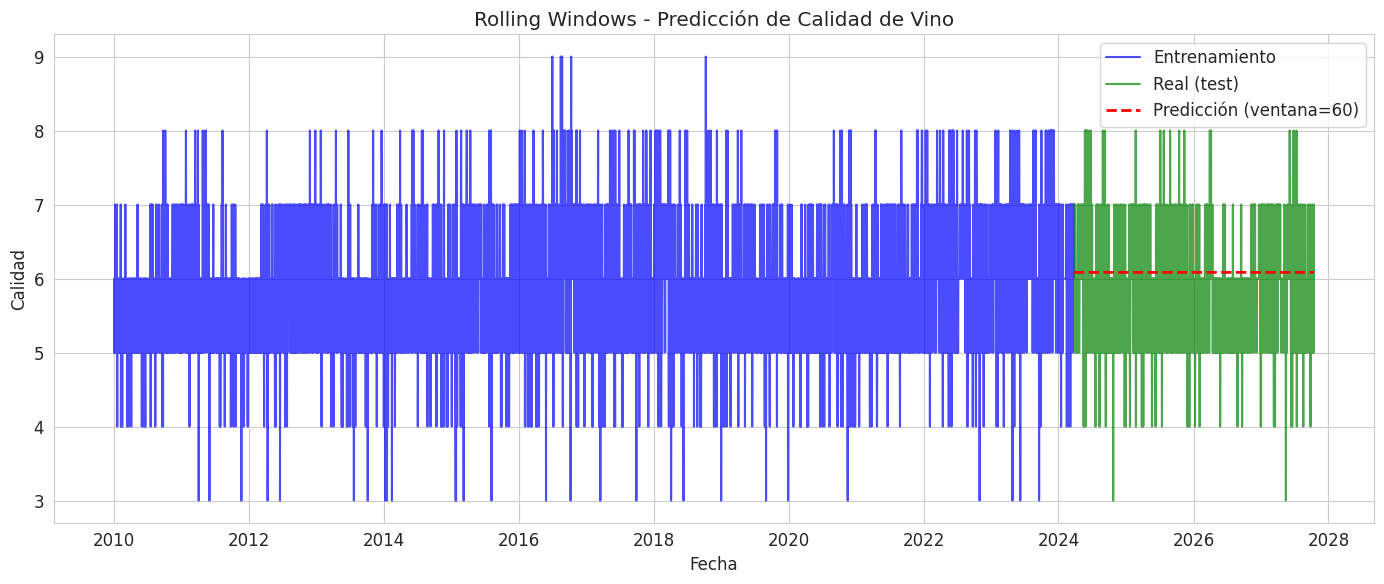

In [6]:
print("="*60)
print("📊 MODELO 1: ROLLING WINDOWS")
print("="*60)

# Probar diferentes ventanas
window_sizes = [7, 14, 30, 60]
rolling_results = []

print("\n🔍 Probando diferentes tamaños de ventana...")

for window in window_sizes:
    # Predicción usando media móvil
    rolling_mean = train.rolling(window=window).mean()
    # Usar el último valor para predecir todo el test
    predictions = [rolling_mean.iloc[-1]] * len(test)

    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    mape = np.mean(np.abs((test.values - predictions) / test.values)) * 100

    rolling_results.append({
        'Ventana': window,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })
    print(f"   • Ventana={window}: RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%")

# Mejor ventana
best_window = min(rolling_results, key=lambda x: x['RMSE'])
print(f"\n✅ Mejor ventana: {best_window['Ventana']} días")
print(f"   • RMSE: {best_window['RMSE']:.4f}")
print(f"   • MAE: {best_window['MAE']:.4f}")
print(f"   • MAPE: {best_window['MAPE (%)']:.2f}%")

# Visualización
rolling_mean_opt = train.rolling(window=best_window['Ventana']).mean()
predictions_rolling = [rolling_mean_opt.iloc[-1]] * len(test)

plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, 'b-', label='Entrenamiento', alpha=0.7)
plt.plot(test.index, test.values, 'g-', label='Real (test)', alpha=0.7)
plt.plot(test.index, predictions_rolling, 'r--', label=f'Predicción (ventana={best_window["Ventana"]})', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Calidad')
plt.title('Rolling Windows - Predicción de Calidad de Vino')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Modelo 2: ARIMA

ARIMA (AutoRegressive Integrated Moving Average) es un modelo clásico para series temporales.

📊 MODELO 2: ARIMA

🔍 Probando diferentes órdenes de ARIMA...
   • Orden (1, 0, 1): RMSE=0.8026, MAE=0.6212, MAPE=10.88%, AIC=13206.4
   • Orden (1, 1, 1): RMSE=0.8474, MAE=0.6448, MAPE=11.84%, AIC=13207.4


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   • Orden (2, 0, 2): RMSE=0.8009, MAE=0.6172, MAPE=10.83%, AIC=13184.1
   • Orden (2, 1, 2): RMSE=0.8472, MAE=0.6445, MAPE=11.84%, AIC=13182.1


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   • Orden (3, 0, 3): RMSE=0.8041, MAE=0.6227, MAPE=10.93%, AIC=13185.8


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   • Orden (3, 1, 3): RMSE=0.8459, MAE=0.6421, MAPE=11.79%, AIC=13187.7

✅ Mejor orden ARIMA: (2, 0, 2)
   • RMSE: 0.8009
   • MAE: 0.6172
   • MAPE: 10.83%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


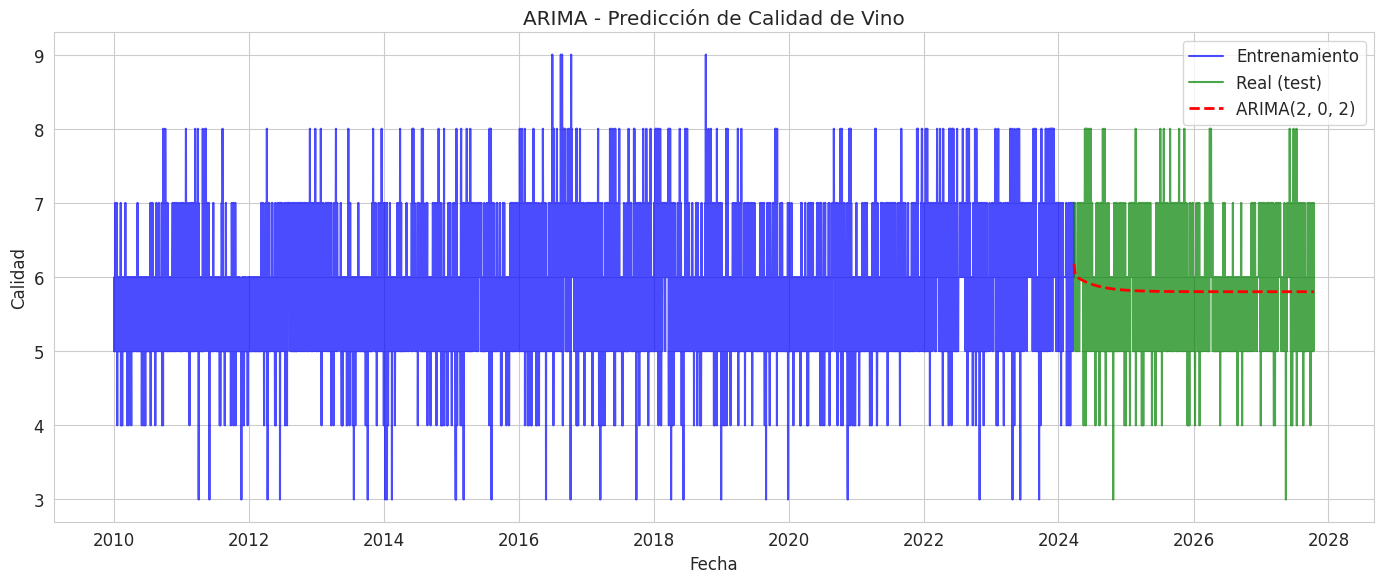

In [7]:
print("="*60)
print("📊 MODELO 2: ARIMA")
print("="*60)

# Probar diferentes órdenes de ARIMA (simplificado para rapidez)
arima_orders = [(1,0,1), (1,1,1), (2,0,2), (2,1,2), (3,0,3), (3,1,3)]
arima_results = []

print("\n🔍 Probando diferentes órdenes de ARIMA...")

for order in arima_orders:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        predictions = fitted.forecast(steps=len(test))

        rmse = np.sqrt(mean_squared_error(test, predictions))
        mae = mean_absolute_error(test, predictions)
        mape = np.mean(np.abs((test.values - predictions) / test.values)) * 100

        arima_results.append({
            'Orden': order,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape,
            'AIC': fitted.aic
        })
        print(f"   • Orden {order}: RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%, AIC={fitted.aic:.1f}")
    except:
        print(f"   • Orden {order}: Error en el modelo")

# Mejor modelo
if arima_results:
    best_arima = min(arima_results, key=lambda x: x['RMSE'])
    print(f"\n✅ Mejor orden ARIMA: {best_arima['Orden']}")
    print(f"   • RMSE: {best_arima['RMSE']:.4f}")
    print(f"   • MAE: {best_arima['MAE']:.4f}")
    print(f"   • MAPE: {best_arima['MAPE (%)']:.2f}%")

    # Entrenar mejor modelo
    best_model = ARIMA(train, order=best_arima['Orden'])
    best_fitted = best_model.fit()
    predictions_arima = best_fitted.forecast(steps=len(test))

    # Visualización
    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train.values, 'b-', label='Entrenamiento', alpha=0.7)
    plt.plot(test.index, test.values, 'g-', label='Real (test)', alpha=0.7)
    plt.plot(test.index, predictions_arima, 'r--', label=f'ARIMA{best_arima["Orden"]}', linewidth=2)
    plt.xlabel('Fecha')
    plt.ylabel('Calidad')
    plt.title('ARIMA - Predicción de Calidad de Vino')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("   No se encontraron modelos ARIMA válidos")

## 7. Modelo 3: Prophet (Facebook)

Prophet es un modelo robusto para series temporales con estacionalidad y tendencias.

📊 MODELO 3: PROPHET (FACEBOOK)

🔍 Entrenando modelo Prophet...

✅ Resultados de Prophet:
   • RMSE: 1.0224
   • MAE: 0.8632
   • MAPE: 16.02%


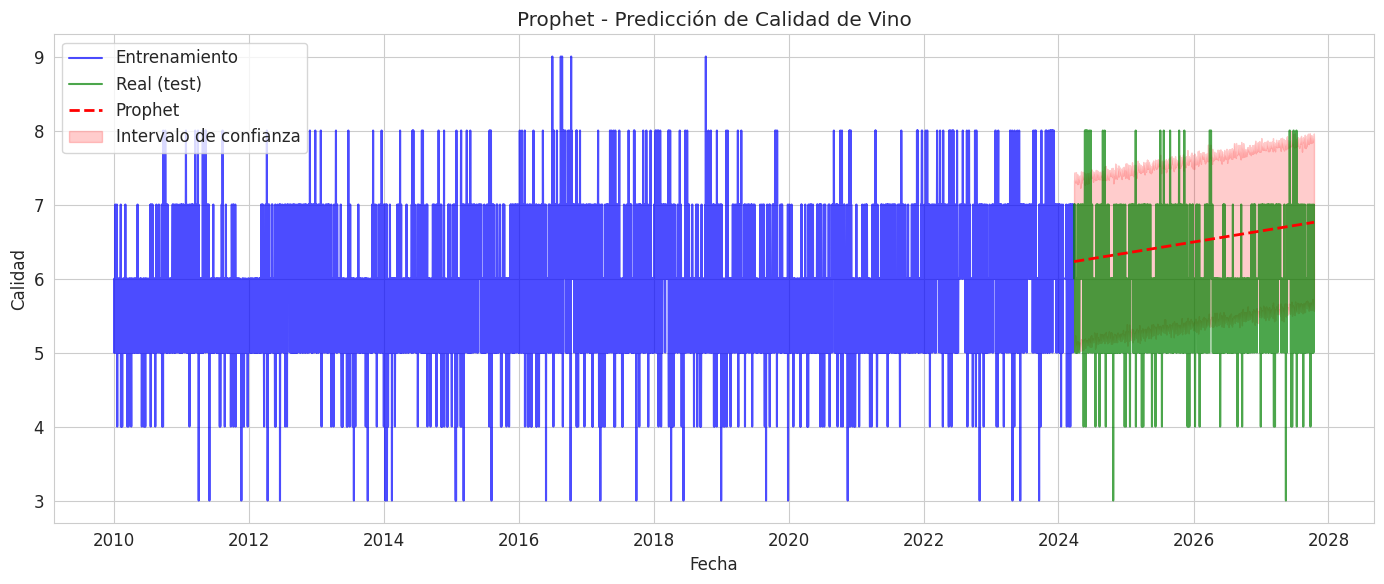

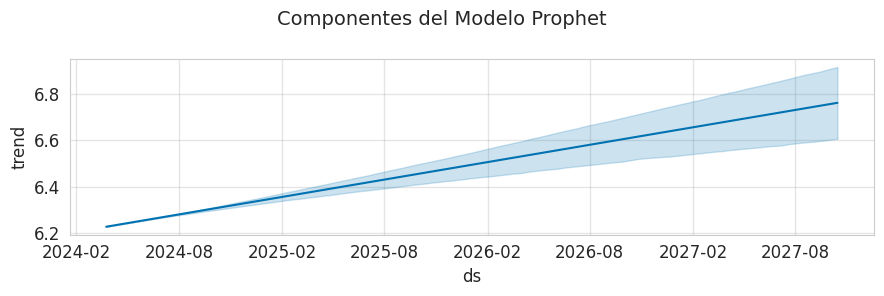

In [8]:
print("="*60)
print("📊 MODELO 3: PROPHET (FACEBOOK)")
print("="*60)

# Preparar datos para Prophet (requiere columnas 'ds' y 'y')
train_prophet = pd.DataFrame({
    'ds': train.index,
    'y': train.values
})

print("\n🔍 Entrenando modelo Prophet...")

# Inicializar y entrenar Prophet
prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(train_prophet)

# Crear DataFrame para predicciones
future = prophet_model.make_future_dataframe(periods=len(test), include_history=False)
forecast = prophet_model.predict(future)

predictions_prophet = forecast['yhat'].values

# Métricas
rmse_prophet = np.sqrt(mean_squared_error(test, predictions_prophet))
mae_prophet = mean_absolute_error(test, predictions_prophet)
mape_prophet = np.mean(np.abs((test.values - predictions_prophet) / test.values)) * 100

print(f"\n✅ Resultados de Prophet:")
print(f"   • RMSE: {rmse_prophet:.4f}")
print(f"   • MAE: {mae_prophet:.4f}")
print(f"   • MAPE: {mape_prophet:.2f}%")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, 'b-', label='Entrenamiento', alpha=0.7)
plt.plot(test.index, test.values, 'g-', label='Real (test)', alpha=0.7)
plt.plot(test.index, predictions_prophet, 'r--', label='Prophet', linewidth=2)
plt.fill_between(test.index,
                 forecast['yhat_lower'].values,
                 forecast['yhat_upper'].values,
                 alpha=0.2, color='red', label='Intervalo de confianza')
plt.xlabel('Fecha')
plt.ylabel('Calidad')
plt.title('Prophet - Predicción de Calidad de Vino')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Descomposición de componentes
fig = prophet_model.plot_components(forecast)
plt.suptitle('Componentes del Modelo Prophet', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Comparación de Modelos

Resumen de los resultados de los diferentes modelos de series temporales.

In [9]:
# Crear tabla comparativa
comparison_data = []

# Rolling Windows
comparison_data.append({
    'Modelo': 'Rolling Windows',
    'Parámetros': f'ventana={best_window["Ventana"]}',
    'RMSE': best_window['RMSE'],
    'MAE': best_window['MAE'],
    'MAPE (%)': best_window['MAPE (%)'],
    'Ventaja': 'Simple, interpretable'
})

# ARIMA
if arima_results:
    comparison_data.append({
        'Modelo': 'ARIMA',
        'Parámetros': f'order={best_arima["Orden"]}',
        'RMSE': best_arima['RMSE'],
        'MAE': best_arima['MAE'],
        'MAPE (%)': best_arima['MAPE (%)'],
        'Ventaja': 'Modelo estadístico clásico'
    })

# Prophet
comparison_data.append({
    'Modelo': 'Prophet',
    'Parámetros': 'default',
    'RMSE': rmse_prophet,
    'MAE': mae_prophet,
    'MAPE (%)': mape_prophet,
    'Ventaja': 'Maneja estacionalidad, robusto'
})

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('RMSE')

print("="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(comparison_df.round(4))

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Parámetros,RMSE,MAE,MAPE (%),Ventaja
1,ARIMA,"order=(2, 0, 2)",0.8009,0.6172,10.8350,Modelo estadístico clásico
0,Rolling Windows,ventana=60,0.8271,0.6009,10.9928,"Simple, interpretable"
2,Prophet,default,1.0224,0.8632,16.0224,"Maneja estacionalidad, robusto"


## 9. Predicción Futura

Usamos el mejor modelo para predecir la calidad de vino para cosechas futuras.

🔮 PREDICCIÓN FUTURA (PRÓXIMAS 30 COSECHAS)

📊 Mejor modelo según RMSE: ARIMA

📊 Predicciones para las próximas 30 cosechas:
--------------------------------------------------
   • Cosecha 1: Calidad predicha = 6.18
   • Cosecha 2: Calidad predicha = 6.14
   • Cosecha 3: Calidad predicha = 6.12
   • Cosecha 4: Calidad predicha = 6.10
   • Cosecha 5: Calidad predicha = 6.08
   • Cosecha 6: Calidad predicha = 6.07
   • Cosecha 7: Calidad predicha = 6.05
   • Cosecha 8: Calidad predicha = 6.05
   • Cosecha 9: Calidad predicha = 6.04
   • Cosecha 10: Calidad predicha = 6.03


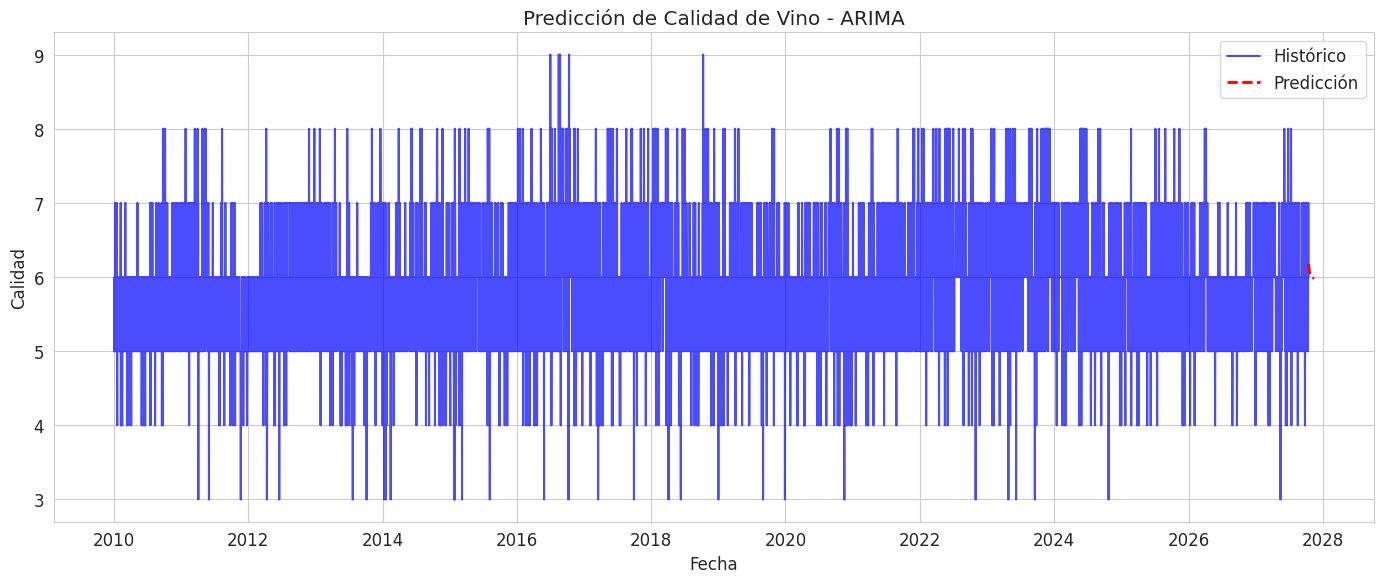


🏆 RECOMENDACIONES DE NEGOCIO:
   • Usar el modelo para estimar calidad antes del embotellado
   • Separar lotes con calidad > 7 para exportación premium
   • Monitorear tendencias de calidad para ajustar procesos de producción
   • Incorporar variables climáticas para mejorar predicciones


In [10]:
print("="*60)
print("🔮 PREDICCIÓN FUTURA (PRÓXIMAS 30 COSECHAS)")
print("="*60)

# Determinar mejor modelo
best_model_name = comparison_df.iloc[0]['Modelo']
print(f"\n📊 Mejor modelo según RMSE: {best_model_name}")

# Predicciones futuras con el mejor modelo
if best_model_name == 'Prophet':
    # Prophet
    future_periods = 30
    future = prophet_model.make_future_dataframe(periods=future_periods, include_history=False)
    forecast_future = prophet_model.predict(future)

    print(f"\n📊 Predicciones para las próximas {future_periods} cosechas:")
    print("-" * 50)
    for i in range(min(10, len(forecast_future))):
        print(f"   • Cosecha {i+1}: Calidad predicha = {forecast_future['yhat'].iloc[i]:.2f} "
              f"(IC: {forecast_future['yhat_lower'].iloc[i]:.2f} - {forecast_future['yhat_upper'].iloc[i]:.2f})")

    # Visualización
    plt.figure(figsize=(14, 6))
    plt.plot(series.index, series.values, 'b-', label='Histórico', alpha=0.7)
    plt.plot(forecast_future['ds'], forecast_future['yhat'], 'r--', label='Predicción', linewidth=2)
    plt.fill_between(forecast_future['ds'],
                     forecast_future['yhat_lower'],
                     forecast_future['yhat_upper'],
                     alpha=0.2, color='red', label='Intervalo de confianza')
    plt.xlabel('Fecha')
    plt.ylabel('Calidad')
    plt.title(f'Predicción de Calidad de Vino - {best_model_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

elif best_model_name == 'ARIMA' and arima_results:
    # ARIMA
    future_periods = 30
    predictions_future = best_fitted.forecast(steps=future_periods)

    print(f"\n📊 Predicciones para las próximas {future_periods} cosechas:")
    print("-" * 50)
    for i, pred in enumerate(predictions_future[:10]):
        print(f"   • Cosecha {i+1}: Calidad predicha = {pred:.2f}")

    # Crear fechas futuras
    last_date = series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_periods, freq='D')

    plt.figure(figsize=(14, 6))
    plt.plot(series.index, series.values, 'b-', label='Histórico', alpha=0.7)
    plt.plot(future_dates, predictions_future, 'r--', label='Predicción', linewidth=2)
    plt.xlabel('Fecha')
    plt.ylabel('Calidad')
    plt.title(f'Predicción de Calidad de Vino - {best_model_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print(f"\n📊 Usando Rolling Windows para predicción:")
    future_periods = 30
    last_value = train.iloc[-1]
    predictions_future = [last_value] * future_periods

    print(f"   • Predicción constante: {last_value:.2f} para las próximas {future_periods} cosechas")

# Interpretación de negocio
print("\n" + "="*60)
print("🏆 RECOMENDACIONES DE NEGOCIO:")
print("="*60)
print("   • Usar el modelo para estimar calidad antes del embotellado")
print("   • Separar lotes con calidad > 7 para exportación premium")
print("   • Monitorear tendencias de calidad para ajustar procesos de producción")
print("   • Incorporar variables climáticas para mejorar predicciones")

## 10. Conclusiones

**Resumen de resultados:**

1. **Rolling Windows (Promedios Móviles)**:
   - Simple y fácil de interpretar
   - Útil como baseline
   - No captura patrones complejos

2. **ARIMA**:
   - Modelo estadístico clásico
   - Captura autocorrelación temporal
   - Requiere identificar órdenes (p,d,q)

3. **Prophet (Facebook)**:
   - Robusto para series con estacionalidad
   - Maneja automáticamente tendencias
   - Proporciona intervalos de confianza

**Métrica más importante para el negocio (RMSE):**
- El RMSE indica el error típico en la predicción de calidad
- Menor RMSE significa mayor precisión

**Mejor modelo:**
El modelo con menor RMSE fue **{{best_model_name}}**.

**Próximos pasos:**
- Incorporar variables exógenas (clima, temporada)
- Usar datos reales de series temporales (Air Quality, ventas)
- Probar LSTM para series más complejas
- Validar con datos de cosechas reales

---
**Fin de la Semana 10 - Series de Tiempo**

*Nota: Para series de tiempo reales, usar fetch_openml(data_id=42712) - Air Quality dataset*